# Figure 3 — Dominant-negative variants

Panels are built from `output/annotated_combined.tsv` (see `Annotations.ipynb`)
and written to `output/figures/fig3/`.

**The notebook is organised by topic, not by panel letter.** Panels that answer
the same question at different resolutions sit together and share one
explanation — the three structural-enrichment panels, the structures with their
position maps, and the two population-depletion panels — so the reasoning reads
once instead of three times. The panel letters below are the figure's order, not
this notebook's.

| Panel | Content |
|---|---|
| 3A | SHP2 activity histogram with the DN threshold and control boxplots |
| 3B | Per-protein DN counts table |
| 3C | Structural-enrichment odds ratios, pooled over proteins, by variant type |
| 3D | Per-protein DN composition across Buried / Active site / Interface |
| 3E–G, S3C–E, S3G | Structures with DN spheres, paired with position tracks |
| S3A | Per-protein squares: count, odds ratio, significance |
| 3I | Depletion in gnomAD / All of Us / GENIE, pooled |
| S3B | phyloP and kinase-JSD conservation at DN vs non-DN positions |
| S3F | Per-protein depletion heatmap |

**Definitions used throughout.** A dominant negative is a variant whose pathway
activity falls below the per-library empty-vector baseline — see
`Annotations.ipynb` Step 4 for the four restrictions. Structural categories
follow the v4 ontology: **B**uried is `relative_sasa < 0.25 and not active
site` (so B and AS are mutually exclusive by construction, which is what lets
the category extend to single-residue deletions), **AS** is the annotated
active-site flag, and **I** is membership in a curated PDB interface.

In [1]:
%load_ext autoreload
%autoreload 2
# Edits to utils.py take effect without restarting the kernel. Note that
# autoreload re-executes changed module bodies, so any module-level constant
# reassigned from the notebook (e.g. utils.BUFFERING_COLORS = ...) is reset on
# reload — pass such overrides as function arguments instead.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import utils
from utils import ANNOTATED_COMBINED, OUTPUT

utils.apply_style()
FIG = OUTPUT / "figures" / "fig3"
FIG.mkdir(parents=True, exist_ok=True)
pd.set_option("display.width", 170)

COLS = ["protein", "library", "assay", "assay_treatment", "variant",
        "Mutation Type", "variant_category", "Wild Type Residue", "Mutation",
        "Position",
        "average score", "classification_2.5pct", "DN_EV", "dn_threshold",
        "domain", "relative_sasa", "dssp_secondary_structure", "active_site",
        "interface_pdb_curated", "interface_partners", "n_interface_partners",
        "inter_domain_contacts_all_atom", "phylop_vert", "jsd_conservation",
        "ddG_SPURS", "in_gnomad", "in_aou",
        "genie_count",
        "min_nt_changes", "gnomad_mappable", "nmd_zone"]

### Analysis helpers

Defined here rather than in `utils.py`, which is rendering-only: the tests
behind a figure should be readable next to it. Benjamini–Hochberg comes from
`scipy.stats.false_discovery_control` rather than a hand-rolled version; it
requires finite input, so the wrapper carries NaNs through untouched and
corrects only over the tests that actually ran.

In [3]:
from scipy import stats
from scipy.stats.contingency import odds_ratio as conditional_odds_ratio


def fisher_or(n_in_a, n_out_a, n_in_b, n_out_b):
    '''Conditional-MLE odds ratio, exact 95% CI, two-sided Fisher p.

    2x2 is [[in_a, out_a], [in_b, out_b]] — typically DN in/out of a feature
    over non-DN in/out. Exact intervals rather than Woolf/Haldane because they
    stay defined when a cell is zero, which is common per protein.
    '''
    table = np.array([[n_in_a, n_out_a], [n_in_b, n_out_b]])
    out = dict(n_in_a=n_in_a, n_out_a=n_out_a, n_in_b=n_in_b, n_out_b=n_out_b,
               or_=np.nan, ci_low=np.nan, ci_high=np.nan, p=np.nan)
    if table.sum() == 0 or (table.sum(axis=1) == 0).any():
        return out
    try:
        res = conditional_odds_ratio(table)
        ci = res.confidence_interval(0.95)
        out["or_"], out["ci_low"], out["ci_high"] = res.statistic, ci.low, ci.high
    except Exception:
        pass
    out["p"] = stats.fisher_exact(table)[1]
    return out


def bh(pvals):
    '''BH q-values via scipy, NaN-safe. NaNs pass through and are excluded
    from the family, so the correction is over the tests actually performed.'''
    p = np.asarray(pvals, dtype=float)
    q = np.full_like(p, np.nan)
    ok = np.isfinite(p)
    if ok.any():
        q[ok] = stats.false_discovery_control(p[ok], method="bh")
    return q


def stars(q):
    '''*** q<0.001, ** q<0.01, * q<0.05.'''
    if q is None or not np.isfinite(q):
        return ""
    return "***" if q < 1e-3 else "**" if q < 1e-2 else "*" if q < 0.05 else ""


def enrichment(df, feature_cols, group_col, group_by=None):
    '''DN-vs-non-DN odds ratio for each boolean feature, BH-corrected over
    the returned family.'''
    rows = []
    strata = [(None, df)] if group_by is None else list(df.groupby(group_by))
    for stratum, sub in strata:
        arm = sub[group_col].astype(bool)
        for feat in feature_cols:
            fl = sub[feat].astype(bool)
            r = fisher_or(int((arm & fl).sum()), int((arm & ~fl).sum()),
                          int((~arm & fl).sum()), int((~arm & ~fl).sum()))
            r.update({group_by or "stratum": stratum, "feature": feat})
            rows.append(r)
    out = pd.DataFrame(rows).rename(columns={"or_": "or"})
    out["q"] = bh(out["p"].values)
    out["stars"] = out["q"].map(stars)
    return out


def load_scored(**filters):
    '''Read the combined table with the usual filters. Inline rather than in
    utils so the provenance of every panel's input is visible here.'''
    df = pd.read_csv(ANNOTATED_COMBINED, sep="\t", low_memory=False,
                     usecols=list(dict.fromkeys(COLS)))
    for col, allowed in filters.items():
        if allowed is None:
            continue
        df = df[df[col].isin(set(allowed)) if isinstance(allowed, (set, list, tuple))
                else (df[col] == allowed)]
    return df.reset_index(drop=True)


def activity_group(df):
    '''Four-level activity group, DN taking precedence over 'low' (DN is a
    strict subset of low activity by construction).'''
    g = df["classification_2.5pct"].astype(object).copy()
    g[df["DN_EV"] == True] = "DN"   # noqa: E712 — DN_EV is object dtype
    return g

# Activity baseline only: DN is defined there and nowhere else.
act = load_scored(assay="activity", assay_treatment=utils.BASELINE_TREATMENTS)
print(f"activity baseline rows: {len(act):,}")

dn_pool = act[act.protein.isin(utils.DN_ELIGIBLE)].copy()
dn_pool["is_dn"] = dn_pool.DN_EV == True
print(f"DN-eligible rows: {len(dn_pool):,}   DN: {int(dn_pool.is_dn.sum()):,}")

activity baseline rows: 196,801
DN-eligible rows: 134,670   DN: 13,791


## 3A — how a dominant negative is defined

ERBB2 as the exemplar. The histogram is its pathway-activity distribution;
variants below the empty-vector threshold are red — those are the dominant
negatives. Beneath, on the same axis, sit the two control distributions that
place the threshold: the bootstrapped empty-vector means and the synonymous
variants. The point of the panel is that the DN cutoff sits well below the
synonymous bulk, so a DN call is not simply the low tail of measurement noise.

The empty-vector bootstrap boxplot needs a five-number summary of the
bootstrapped means. Barcode-level `empty_vector_std` scores are not in the
repository — no raw dataframe contains them — so this draws from
`data/empty_vector_score_stats_autogenerated.tsv` if present and otherwise
renders without that one box.

### The empty-vector null, recomputed here

A variant's score is the mean over its barcodes — about ten of them. So the null
a DN call is made against is not "how low does one barcode go" but **"how low
does a ten-barcode mean go when the construct is empty"**. That distribution is
rebuilt below from the control barcodes themselves (`Scoring.ipynb` Step 11
writes them), rather than read from a supplied summary file.

Both controls are shown. `empty_vector_std` carries no cassette and is what the
threshold uses. `NoVar_std` is the older control it replaced; it is plotted only
so the reason for the switch stays visible — it drifts up to 5× across libraries
with cold-shock handling, which is why it anchors nothing.

The distinction matters quantitatively: taking the percentile of the raw barcode
scores instead drops every threshold and would cut the pathway-wide DN count by
roughly two thirds.

In [4]:
# The bootstrap is NOT re-run here. Scoring.ipynb Step 11 does it once, and
# emits both the threshold and the five-number summary of the draw distribution
# it came from, so the panels below show the null the classification actually
# used. A second implementation in this notebook is how a figure drifts from the
# classification it illustrates — which happened once already, when this cell
# still computed empty-vector-only at 2.5% while DN_EV had moved to a pooled 5%.
ev_boot_table = pd.read_csv(utils.DN_THRESHOLDS, sep="\t")
ev_boot_table = ev_boot_table[(ev_boot_table.assay == "activity")
                              & (ev_boot_table.control == "used")]
print(f"thresholds read from {utils.DN_THRESHOLDS.name}: "
      f"{len(ev_boot_table)} activity cells")

ctrl = pd.read_csv(utils.CONTROL_BARCODE_SCORES, sep="\t")
print(f"control barcodes behind them: {len(ctrl):,}")
print(ctrl.groupby("variant").size().rename("barcodes").to_frame().to_string())

_show = (ev_boot_table[ev_boot_table.assay_treatment.isin(
    utils.BASELINE_TREATMENTS)].sort_values("library"))
print("\nthe no-variant null per baseline cell "
      "(2.5th pct of 500 draws of a 10-barcode mean):")
print(_show[["library", "assay_treatment", "n_barcodes", "pooled_novar",
             "dn_threshold", "boot_p2.5", "boot_median", "boot_p97.5",
             "seed_lo", "seed_hi"]]
      .to_string(index=False, float_format=lambda v: f"{v:8.4f}"))

# The classification must agree with the thresholds these panels draw.
_t = act.dropna(subset=["dn_threshold"]).groupby(
    ["library", "assay_treatment"])["dn_threshold"].first()
_j = ev_boot_table.set_index(["library", "assay_treatment"]).dn_threshold
_cmp = pd.concat([_t.rename("in_annotated"), _j.rename("in_thresholds")],
                 axis=1).dropna()
_dev = (_cmp.in_annotated / _cmp.in_thresholds - 1).abs()
print(f"\nthresholds in annotated_combined vs the file: {len(_cmp)} cells, "
      f"max deviation {_dev.max():.4%}")
assert _dev.max() < 1e-6, (
    "annotated_combined was built from different thresholds than these panels "
    "draw — re-run Annotations.ipynb:\n" + _cmp[_dev > 1e-6].to_string())

# --- specificity: how often does the threshold call a SYNONYMOUS variant? ---
# Synonymous variants are excluded from DN_EV by the protein-altering filter, so
# they are never *called* — which is exactly why they make a free negative
# control. A threshold that separates function from noise should leave them
# alone. Where it does not, the DN calls in that cell are not measuring
# dominant negativity.
_a = act[~act.protein.isin(utils.INHIBITORY_PROTEINS)]
spec = []
for (lib, tr), g in _a.groupby(["library", "assay_treatment"]):
    row = ev_boot_table[(ev_boot_table.library == lib)
                        & (ev_boot_table.assay_treatment == tr)]
    if not len(row):
        continue
    thr = float(row.dn_threshold.iloc[0])
    syn = g.loc[g["Mutation Type"] == "synonymous wild type", "average score"].dropna()
    mis = g.loc[g["Mutation Type"] == "missense", "average score"].dropna()
    if not len(syn) or not len(mis):
        continue
    spec.append({"library": lib, "n_syn": len(syn),
                 "syn_below_pct": 100 * (syn < thr).mean(),
                 "mis_below_pct": 100 * (mis < thr).mean(),
                 "ctrl_over_syn": float(row.boot_median.iloc[0]) / syn.median(),
                 "enrichment": ((mis < thr).mean() / (syn < thr).mean()
                                if (syn < thr).any() else np.inf)})
spec = pd.DataFrame(spec).sort_values("syn_below_pct", ascending=False)
print("\nDN threshold specificity — synonymous are the free negative control:")
print(spec.to_string(index=False, float_format=lambda v: f"{v:8.2f}"))

_bad = spec[spec.syn_below_pct > 5]
if len(_bad):
    print(f"\n  WARNING: {len(_bad)} cell(s) call >5% of synonymous variants:")
    for r in _bad.itertuples():
        print(f"    {r.library}: {r.syn_below_pct:.1f}% of synonymous below the "
              f"threshold, missense only {r.enrichment:.1f}x enriched over them. "
              f"The no-variant control sits at {r.ctrl_over_syn:.2f}x the "
              "synonymous median"
              + (" — ABOVE wild-type-like, so 'below the control' cannot mean "
                 "dominant negative here." if r.ctrl_over_syn > 1 else "."))
    print("  DN counts from these cells should not be used as they stand.")


thresholds read from dn_thresholds_recomputed.tsv: 24 activity cells
control barcodes behind them: 84,345
                  barcodes
variant                   
NoVar_std             8074
empty_vector_std     76271

the no-variant null per baseline cell (2.5th pct of 500 draws of a 10-barcode mean):
   library assay_treatment  n_barcodes  pooled_novar  dn_threshold  boot_p2.5  boot_median  boot_p97.5  seed_lo  seed_hi
araf_cterm    No_treatment        6058          True        0.6163     0.6157       0.7133      0.8541   0.6037   0.6263
araf_nterm    No_treatment        1171          True        0.5220     0.5182       0.6027      0.7130   0.5129   0.5323
braf_cterm    No_treatment         365         False        0.9153     0.9379       1.0715      1.2441   0.8960   0.9314
braf_nterm    No_treatment         861         False        0.7300     0.7285       0.8573      0.9911   0.7147   0.7458
craf_cterm    No_treatment        5629          True        0.2573     0.2581       0.3024     


DN threshold specificity — synonymous are the free negative control:
   library  n_syn  syn_below_pct  mis_below_pct  ctrl_over_syn  enrichment
braf_cterm    316          15.82          39.00           1.08        2.46
       ret    423           0.24          17.99           0.88       76.12
      shp2    541           0.18          20.89           0.91      113.02
braf_nterm    371           0.00           2.82           0.85         inf
craf_cterm    292           0.00           5.70           0.31         inf
araf_cterm    291           0.00          49.23           0.70         inf
araf_nterm    267           0.00           3.03           0.60         inf
      egfr    442           0.00           3.19           0.20         inf
craf_nterm    304           0.00           0.00           0.20         inf
     erbb2    462           0.00           0.32           0.37         inf
      kras    180           0.00           6.07           0.22         inf
      mras    200           0.

SHP2: missense 10,689, 3nt deletion 810, nonsense 569, synonymous 541
excluded from the panel: other 601, frameshift 586


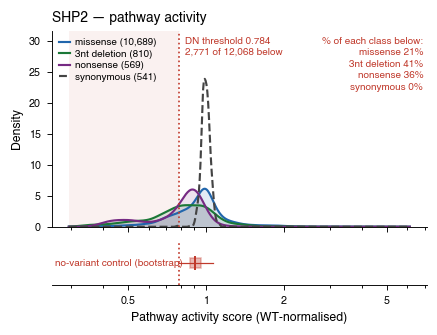

,n,n_dn,% of class that is DN,% of DN pool,in panel
variant_category,,,,,
missense,10689,2233,20.9,70.6,True
3nt deletion,810,336,41.5,10.6,True
nonsense,569,202,35.5,6.4,True
frameshift,586,143,24.4,4.5,False
other,601,248,41.3,7.8,False


In [5]:
EXEMPLAR = "shp2"
# SHP2 rather than ERBB2: it carries far more DN_EV calls, so the DN block is
# actually visible, and its autoinhibitory mechanism is the one
# the ontology's inter-domain contact feature was added for.

# One area-normalised density per class rather than stacked counts. Missense
# outnumbers 3nt deletions 13:1 and nonsense 19:1, so on a count axis the two
# rarer classes are invisible; normalised, the panel shows what it is meant to —
# that deletions and nonsense sit lower on the activity axis than missense, which
# is why they are enriched among DNs.
CLASSES = ["missense", "3nt deletion", "nonsense"]
prot = act[act.protein == EXEMPLAR]
sub = prot[prot.variant_category.isin(CLASSES)]
thresh = float(prot.dn_threshold.dropna().iloc[0])

density_groups = [
    (c, sub.loc[sub.variant_category == c, "average score"].dropna().values,
     utils.VARIANT_CATEGORY_COLORS[c])
    for c in CLASSES if (sub.variant_category == c).any()]

# Synonymous on the same axis, dashed and grey: it is the wild-type reference,
# not a library variant class. It is what "no functional change" looks like
# after the same measurement and scoring, so it sets the width the other curves
# should be read against — and its own fraction below the threshold is the
# false-positive rate the DN call is buying.
_syn = (prot.loc[prot["Mutation Type"] == "synonymous wild type",
                 "average score"].dropna().values)
if len(_syn) >= 5:
    density_groups.append(("synonymous", _syn, "#444444", "--"))

print(f"{utils.protein_label(EXEMPLAR)}: "
      + ", ".join(f"{e[0]} {len(e[1]):,}" for e in density_groups))

# `frameshift` and `other` are left out of the panel, not hidden: frameshifts
# truncate the protein and say nothing about a folded variant's activity, and
# `other` is a mixed bag (multi-mutants, larger deletions) with no single
# interpretation. Both are in the table below.
_left_out = prot[~prot.variant_category.isin(CLASSES)
                 & prot.variant_category.isin(["frameshift", "other"])]
print("excluded from the panel: "
      + ", ".join(f"{k} {v:,}" for k, v in
                  _left_out.variant_category.value_counts().items()))

# Empty-vector bootstrap only. The synonymous box is dropped: with densities on
# the main axis the synonymous distribution would be a third way of saying where
# wild-type-like sits, and the empty vector is the one the threshold comes from.
ev_boot = None
# ev_boot_table now carries one row per cell for the control set actually used
# (empty vector pooled with NoVar_std in untreated cells), so there is no
# per-control column to select on any more.
_row = ev_boot_table[(ev_boot_table.library == EXEMPLAR)
                     & ev_boot_table.assay_treatment.isin(
                         utils.BASELINE_TREATMENTS)]
if len(_row):
    ev_boot = _row.iloc[0].to_dict()
else:
    print(f"note: no empty-vector barcodes for {EXEMPLAR} — box omitted")

boxes = []
if ev_boot is not None:
    boxes.append(("no-variant control (bootstrap)",
                  {"p2.5": ev_boot.get("boot_p2.5"),
                   "p25": ev_boot.get("boot_p25"),
                   "median": ev_boot.get("boot_median"),
                   "p75": ev_boot.get("boot_p75"),
                   "p97.5": ev_boot.get("boot_p97.5")},
                  utils.ACTIVITY_COLORS["DN"]))

# "n below" counts the library classes; synonymous is a control and is not
# part of the variant pool the threshold is applied to.
_all = np.concatenate([e[1] for e in density_groups if e[0] != "synonymous"])
fig, _ = utils.plot_activity_histogram(
    _all, dn_threshold=thresh, density_groups=density_groups,
    box_distributions=boxes, figsize=(4.4, 3.0),
    title=f"{utils.protein_label(EXEMPLAR)} — pathway activity",
)
utils.save_figure(fig, FIG / f"fig3a_dn_definition_{EXEMPLAR}")
plt.show()

_tbl = prot[prot.variant_category.isin(
    utils.VARIANT_CATEGORY_ORDER)].copy()
_tbl["dn"] = _tbl["average score"] < thresh
comp = _tbl.groupby("variant_category").agg(n=("dn", "size"), n_dn=("dn", "sum"))
comp["% of class that is DN"] = (100 * comp.n_dn / comp.n).round(1)
comp["% of DN pool"] = (100 * comp.n_dn / comp.n_dn.sum()).round(1)
comp["in panel"] = [c in CLASSES for c in comp.index]
display(comp.reindex([c for c in utils.VARIANT_CATEGORY_ORDER
                      if c in comp.index]))


### The same view for every library

3A shows one library in detail. The threshold is set per library, though, and a
reader has no way to tell from a single exemplar whether it behaves the same
everywhere. Here is the same panel for all of them, on one shared axis.

What to look for is the **grey dashed synonymous curve relative to the dotted
threshold**. Synonymous variants are excluded from DN by construction, so any
that fall below the line are false positives the threshold would have accepted —
the specificity number printed in each panel. Almost every library sits at zero.
BRAF C-term does not, and the panel shows why: its no-variant control sits
*above* its wild-type-like distribution, so the threshold cuts into the middle
of synonymous rather than below it.

15 panels, one per DN-eligible library (excluded proteins: ['grb2', 'ksr1', 'ksr2', 'mek1', 'mek2'])


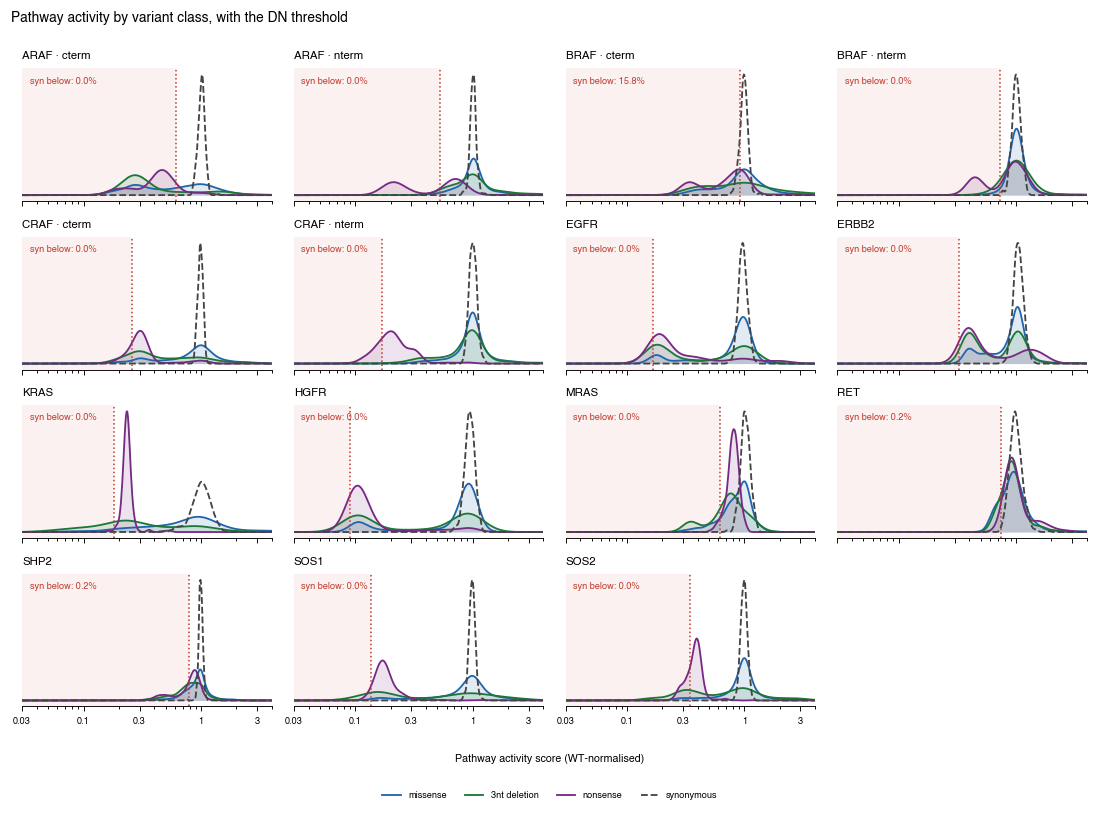


synonymous false-positive rate per panel:
       panel  syn_below_%
BRAF · cterm        15.80
         RET         0.20
        SHP2         0.20
BRAF · nterm         0.00
CRAF · cterm         0.00
ARAF · cterm         0.00
ARAF · nterm         0.00
        EGFR         0.00
CRAF · nterm         0.00
       ERBB2         0.00
        KRAS         0.00
        MRAS         0.00
        HGFR         0.00
        SOS1         0.00
        SOS2         0.00


In [6]:
CLASSES_G = ["missense", "3nt deletion", "nonsense"]

# One panel per unit the THRESHOLD is computed on. That is the library while
# Scoring.ipynb has POOL_HALVES = False (each half of a split library gets its
# own empty vector and its own threshold), and would be the
# protein if it were True. Keying the panels off `pool_protein` rather than
# hard-coding either keeps the figure honest if that flag changes — a protein
# with two thresholds cannot be drawn as one line.
#
# GRB2, MEK1, MEK2, KSR1 and KSR2 are excluded throughout: their wild-type
# overexpression *lowers* pathway activity, so scoring below the empty vector is
# the expected wild-type phenotype rather than dominant negativity.
_thr = ev_boot_table[ev_boot_table.assay_treatment.isin(
    utils.BASELINE_TREATMENTS)].set_index("library")

panels, _skipped = [], []
for lib in sorted(act.library.unique()):
    g = act[act.library == lib]
    prot = g.protein.iloc[0]
    if prot in utils.INHIBITORY_PROTEINS:
        continue
    if lib not in _thr.index:
        _skipped.append(lib)
        continue
    thr = float(_thr.loc[lib, "dn_threshold"])
    groups = [(c, g.loc[g.variant_category == c, "average score"].dropna().values,
               utils.VARIANT_CATEGORY_COLORS[c])
              for c in CLASSES_G if (g.variant_category == c).any()]
    syn = g.loc[g["Mutation Type"] == "synonymous wild type",
                "average score"].dropna().values
    if len(syn) >= 5:
        groups.append(("synonymous", syn, "#444444", "--"))
    if not groups:
        _skipped.append(lib)
        continue
    half = lib.split("_")[-1] if lib.endswith(("_nterm", "_cterm")) else ""
    title = utils.protein_label(prot) + (f" · {half}" if half else "")
    note = f"syn below: {100 * (syn < thr).mean():.1f}%" if len(syn) else ""
    panels.append((title, groups, thr, note))

# a DN-eligible library must not vanish from the figure without saying so
_eligible = {l for l in act.library.unique()
             if act.loc[act.library == l, "protein"].iloc[0]
             not in utils.INHIBITORY_PROTEINS}
assert not _skipped, f"DN-eligible libraries with no panel: {_skipped}"
assert len(panels) == len(_eligible), (
    f"{len(panels)} panels for {len(_eligible)} DN-eligible libraries")
print(f"{len(panels)} panels, one per DN-eligible library "
      f"(excluded proteins: {sorted(utils.INHIBITORY_PROTEINS)})")

# Window set deliberately rather than by a shared percentile. Left to 0.03 so
# HGFR and KRAS -- whose thresholds sit at 0.09 and 0.18 -- are not clipped;
# right to 4, which drops the activating tail. Nothing above ~3 bears on where
# the DN line falls, and cutting it stops the low end being squeezed.
fig, _ = utils.plot_density_grid(
    panels, ncols=4, xlim=(0.03, 4.0),
    suptitle="Pathway activity by variant class, with the DN threshold")
utils.save_figure(fig, FIG / "figs3a_dn_definition_all_libraries")
plt.show()

_spec = pd.DataFrame([{"panel": t, "syn_below_%": float(n.split(": ")[1].rstrip("%"))}
                      for t, _g, _thr, n in panels if n])
print("\nsynonymous false-positive rate per panel:")
print(_spec.sort_values("syn_below_%", ascending=False)
      .to_string(index=False, float_format=lambda v: f"{v:6.2f}"))


## 3B — DN summary table

Columns: **Protein | Domains | Missense | Deletion | Nonsense | Known DNs**.
Cells are `n (percent of that variant type)`, so a protein with few scored
deletions cannot look like a strong signal on count alone.

**Domains** is the architecture of the *full-length* protein from UniProt, not
of the region we assayed. The library tiles only the kinase domain of the RTKs,
so counting the config's domains would wrongly call EGFR/HGFR/RET/ERBB2
single-domain when they are large multi-domain receptors. KRAS and MRAS are the
only genuinely single-domain members — their hypervariable region is a lipid
anchor, not a folded domain.

Rows are ordered multi-domain first, then single-domain, and within each group
by descending missense DN rate.

**Known DNs** lists the literature-validated alleles rather than a bare "Yes",
so the table shows what the prior art actually is. These are the
well-established cases only, not an exhaustive search.

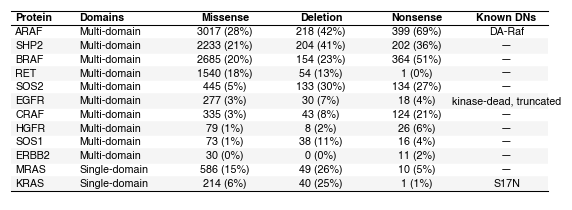

,Protein,Domains,Missense,Deletion,Nonsense,Known DNs
0,ARAF,Multi-domain,3017 (28%),218 (42%),399 (69%),DA-Raf
1,SHP2,Multi-domain,2233 (21%),204 (41%),202 (36%),—
2,BRAF,Multi-domain,2685 (20%),154 (23%),364 (51%),—
3,RET,Multi-domain,1540 (18%),54 (13%),1 (0%),—
4,SOS2,Multi-domain,445 (5%),133 (30%),134 (27%),—
5,EGFR,Multi-domain,277 (3%),30 (7%),18 (4%),"kinase-dead, truncated"
6,CRAF,Multi-domain,335 (3%),43 (8%),124 (21%),—
7,HGFR,Multi-domain,79 (1%),8 (2%),26 (6%),—
8,SOS1,Multi-domain,73 (1%),38 (11%),16 (4%),—
9,ERBB2,Multi-domain,30 (0%),0 (0%),11 (2%),—


In [7]:
# Architecture of the FULL-LENGTH protein (UniProt), not the assayed region.
DOMAIN_ARCHITECTURE = {
    "araf": "Multi-domain", "braf": "Multi-domain", "craf": "Multi-domain",
    "shp2": "Multi-domain",
    "egfr": "Multi-domain", "erbb2": "Multi-domain",
    "met": "Multi-domain", "ret": "Multi-domain",
    "sos1": "Multi-domain", "sos2": "Multi-domain",
    "kras": "Single-domain", "mras": "Single-domain",
}
# Literature-validated dominant negatives, named. Not an exhaustive search.
KNOWN_DNS = {
    "kras": "S17N",
    "egfr": "kinase-dead, truncated",
    "araf": "DA-Raf",
}
MUT_TYPES = ["missense", "deletion", "nonsense"]

records = []
for protein in utils.DN_ELIGIBLE:
    sub = dn_pool[dn_pool.protein == protein]
    dn = sub[sub.is_dn]
    row = {"Protein": utils.protein_label(protein),
           "Domains": DOMAIN_ARCHITECTURE[protein], "_miss_pct": 0.0}
    for mt in MUT_TYPES:
        n_dn = dn.loc[dn["Mutation Type"] == mt, "variant"].nunique()
        n_tot = sub.loc[sub["Mutation Type"] == mt, "variant"].nunique()
        if n_tot > 0:
            pct = 100 * n_dn / n_tot
            if mt == "missense":
                row["_miss_pct"] = pct
            row[mt.capitalize()] = f"{n_dn} ({pct:.0f}%)"
        else:
            row[mt.capitalize()] = str(n_dn)
    row["Known DNs"] = KNOWN_DNS.get(protein, "\u2014")
    records.append(row)

# Multi-domain first, then single-domain; within each, descending missense rate.
tbl = pd.DataFrame(records)
tbl["_is_single"] = (tbl.Domains == "Single-domain").astype(int)
tbl = (tbl.sort_values(["_is_single", "_miss_pct"], ascending=[True, False])
       .drop(columns=["_miss_pct", "_is_single"]).reset_index(drop=True))
tbl = tbl[["Protein", "Domains", "Missense", "Deletion", "Nonsense",
           "Known DNs"]]

fig, _ = utils.plot_dn_summary_table(tbl)
utils.save_figure(fig, FIG / "fig3b_dn_summary_table", formats=("pdf", "svg"))
plt.show()
display(tbl)

---
# Structural context of the DN population

The three panels below answer one question at three resolutions, so they are
kept together: **3C** asks which structural features are enriched among DNs
when every protein is pooled and each variant type is tested separately;
**3D** asks how each protein's own DN population is composed across those
features; **S3A** puts the per-protein odds ratio and the number of variables
it rests on into the same mark, which neither of the other two can show.

Reading them in this order matters. 3C establishes that missense and deletion
DNs are enriched at every structured feature while nonsense DNs are not — the
inversion is the result, because a nonsense at a buried or catalytic residue is
pure loss of function. 3D then shows that the pooled result is not uniform. S3A
shows the spread across proteins is wide
and which proteins carry enough DNs for that to mean anything.

## 3C — structural enrichment, pooled over proteins

Each feature is tested DN vs non-DN **within variant type**, because the
missense/deletion agreement and the nonsense inversion are themselves the
result: missense and deletion DNs are enriched at every structured feature,
whereas nonsense DNs are neutral-to-depleted. A nonsense at a buried or
catalytic residue is pure loss of function — it destroys the protein — so
nonsense DNs avoid those positions and act instead as truncations that leave a
partial poisoning fragment.

Pooling here is deliberate; S3A shows the per-protein spread, which is wide
(burial enrichment varies widely across proteins).

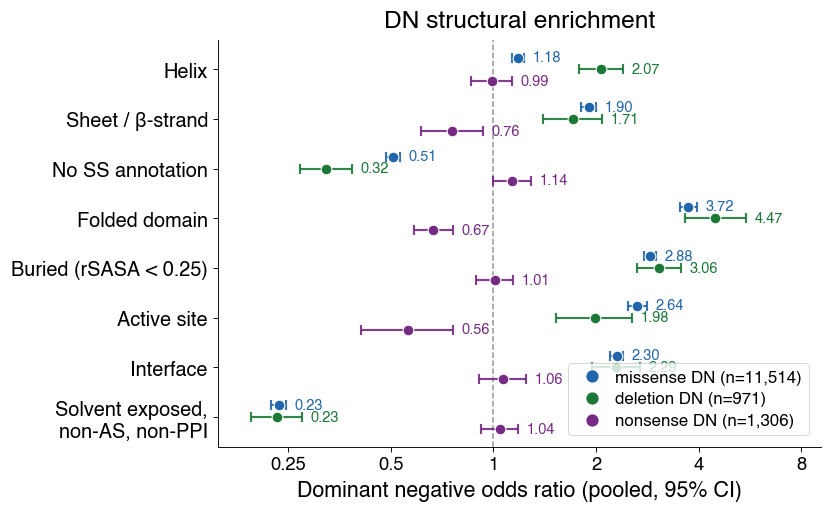

Mutation Type,deletion,missense,nonsense
label,,,
Active site,1.98,2.64,0.56
Buried (rSASA < 0.25),3.06,2.88,1.01
Folded domain,4.47,3.72,0.67
Helix,2.07,1.18,0.99
Interface,2.29,2.30,1.06
No SS annotation,0.32,0.51,1.14
Sheet / β-strand,1.71,1.90,0.76
"Solvent exposed,\nnon-AS, non-PPI",0.23,0.23,1.04


In [8]:
ss = dn_pool.dssp_secondary_structure
rsa = pd.to_numeric(dn_pool.relative_sasa, errors="coerce")

dn_pool["is_helix"] = ss.eq("alpha helix")
dn_pool["is_strand"] = ss.eq("beta strand")
dn_pool["is_no_ss"] = ss.eq("no_ss")
dn_pool["in_domain"] = dn_pool.domain.notna() & dn_pool.domain.ne("none")
dn_pool["is_buried"] = rsa.lt(0.25)
dn_pool["is_active_site"] = dn_pool.active_site.astype(bool)
dn_pool["is_interface"] = dn_pool.interface_pdb_curated.astype(bool)
dn_pool["is_exposed_other"] = (rsa.ge(0.25) & ~dn_pool.is_active_site
                               & ~dn_pool.is_interface)

FEATURES = {
    "is_helix": "Helix",
    "is_strand": "Sheet / β-strand",
    "is_no_ss": "No SS annotation",
    "in_domain": "Folded domain",
    "is_buried": "Buried (rSASA < 0.25)",
    "is_active_site": "Active site",
    "is_interface": "Interface",
    "is_exposed_other": "Solvent exposed,\nnon-AS, non-PPI",
}

rows = []
for vtype in ("missense", "deletion", "nonsense"):
    sub = dn_pool[dn_pool["Mutation Type"] == vtype]
    r = enrichment(sub, list(FEATURES), group_col="is_dn")
    r["Mutation Type"] = vtype
    r["n_dn"] = int(sub.is_dn.sum())
    rows.append(r)
enr = pd.concat(rows, ignore_index=True)
enr["label"] = enr.feature.map(FEATURES)
enr.to_csv(FIG / "fig3c_structural_enrichment.tsv", sep="\t", index=False)

fig, ax = utils.plot_forest(
    enr, label_col="label",
    label_order=[FEATURES[k] for k in FEATURES],
    series_col="Mutation Type", series_order=utils.VARIANT_TYPE_ORDER,
    series_colors=utils.VARIANT_TYPE_COLORS,
    series_n=enr.drop_duplicates("Mutation Type")
               .set_index("Mutation Type")["n_dn"].to_dict(),
    xlabel="Dominant negative odds ratio (pooled, 95% CI)",
    title="DN structural enrichment")
utils.save_figure(fig, FIG / "fig3c_structural_enrichment_forest")
plt.show()
display(enr.pivot(index="label", columns="Mutation Type", values="or").round(2))

## 3D — what explains each protein's DN population

Enrichment (3C) and explanation are different questions: a feature can be
strongly preferred by DN variants while still accounting for few of them. This
panel partitions each protein's missense + deletion DNs into the v4 categories
and their overlaps, so the residual "Other" fraction is visible. SHP2 carries
the largest unassigned share — consistent with a mechanism routed through its
*intramolecular* autoinhibitory interface, which a scheme built on burial,
catalysis and intermolecular interfaces necessarily scores as unexplained.

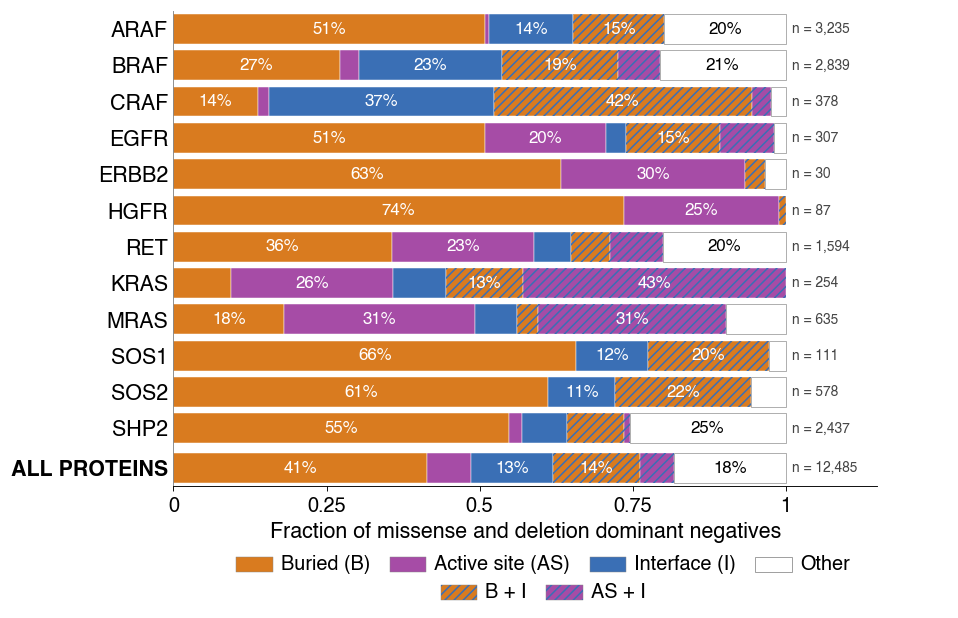

pooled (n=12,485): B_only 41.5%, none 18.3%, B_I 14.1%, I_only 13.4%, AS_only 7.2%, AS_I 5.6%
exactly one category 62.0%; more than one 19.7%; none 18.3%


In [9]:
md_dn = dn_pool[dn_pool.is_dn
                & dn_pool["Mutation Type"].isin(["missense", "deletion"])].copy()
# v4: B excludes the active site, so B and AS cannot co-occur.
md_dn["B"] = md_dn.is_buried & ~md_dn.is_active_site
md_dn["AS"] = md_dn.is_active_site
md_dn["I"] = md_dn.is_interface

# v4's six buckets. B excludes the active site by construction, so B+AS
# (and B+AS+I) cannot occur — six buckets, not seven.
def _bucket(r):
    on = tuple(k for k in ("B", "AS", "I") if r[k])
    return {(): "none", ("B",): "B_only", ("AS",): "AS_only",
            ("I",): "I_only", ("B", "I"): "B_I",
            ("AS", "I"): "AS_I"}[on]

md_dn["bucket"] = md_dn.apply(_bucket, axis=1)
frac = (md_dn.groupby(["protein", "bucket"]).size().unstack(fill_value=0)
        .reindex(columns=utils.ONTOLOGY_BUCKET_ORDER, fill_value=0))
counts = frac.sum(axis=1)
frac = frac.div(counts, axis=0).reindex(
    [p for p in utils.DN_ORDER if p in frac.index])

# Pooled bar, separated from the per-protein rows by a wider gutter.
POOLED = "ALL PROTEINS"   # bolded, separated by a wider gutter
pooled_counts = md_dn.bucket.value_counts()
frac.loc[POOLED] = (pooled_counts / pooled_counts.sum()).reindex(
    utils.ONTOLOGY_BUCKET_ORDER).fillna(0.0)
counts.loc[POOLED] = len(md_dn)

fig, _ = utils.plot_stacked_hbar(
    frac, counts=counts, pooled_row=POOLED,
    legend_rows=utils.ONTOLOGY_LEGEND_ROWS,
    xlabel="Fraction of missense and deletion dominant negatives")
utils.save_figure(fig, FIG / "fig3d_dn_ontology_composition")
plt.show()

pooled = md_dn.bucket.value_counts(normalize=True)
print(f"pooled (n={len(md_dn):,}): "
      + ", ".join(f"{k} {v:.1%}" for k, v in pooled.items()))
# Bucket names are B_only / AS_only / I_only / B_I / AS_I / none -- reindexing
# on anything else silently yields all-zero percentages, so the assertion below
# checks they sum to 1.
single = pooled.reindex(["B_only", "AS_only", "I_only"]).fillna(0).sum()
multi = pooled.reindex(["B_I", "AS_I"]).fillna(0).sum()
none = float(pooled.get("none", 0.0))
assert abs(single + multi + none - 1.0) < 1e-9, "buckets do not sum to 1"
print(f"exactly one category {single:.1%}; "
      f"more than one {multi:.1%}; none {none:.1%}")

## S3A — per-protein enrichment and population size together

Square area is the number of DN variants in the category and fill is the log
odds ratio, so a strong ratio resting on twelve variants and one resting on
twelve hundred are visibly different — which a heatmap alone cannot show. A
bold border marks BH q < 0.05.

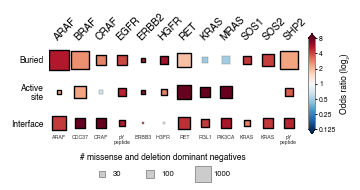

protein,araf,braf,craf,egfr,erbb2,met,ret,kras,mras,sos1,sos2,shp2
category,,,,,,,,,,,,
AS,2.31,2.30,0.67,4.99,5.80,2.83,9.27,8.99,9.00,NaN,NaN,3.53
B,5.31,2.57,2.80,3.99,5.49,5.84,1.88,0.46,0.48,4.33,4.18,2.30
I,4.31,7.98,15.01,5.20,4.88,1.01,4.59,4.31,5.44,2.90,4.36,4.89


In [10]:
# S3A needs one more definition than 3C/3D: the *I* cell is not the pooled
# interface union but the single DOMINANT interface partner.
#
# It is chosen as the HIGHEST-OR partner among those that fire (OR > 1 and BH
# q < 0.001, BH taken within the protein's own partner family), subject to a
# minimum surface size so a tiny surface cannot win on a fragile ratio.
#
# This replaces selecting by DN count, which was wrong for a specific reason:
# across a protein's partners, DN count tracks SURFACE SIZE almost perfectly,
# so "most DNs" reduces to "biggest surface" — and the biggest surface is not the
# most enriched one. For SHP2 that named MPZL1's broad surface over the far more
# enriched N-SH2 phosphotyrosine pocket; MPZL1 contains that pocket plus peripheral
# contacts that dilute it. All eight SHP2 partners are pY-mediated SH2 ligands,
# so they measure one surface at different radii, and the tightest radius is the
# one worth naming.
#
# Restricting to firing partners first still stops a heavily populated but
# *depleted* surface (the EGFR asymmetric dimer face, OR < 1) being nominated as
# "top" on an enrichment plot.
MIN_PARTNER_POSITIONS = 3     # floor to be TESTED at all, unique positions
MIN_TOP_POSITIONS = 10        # floor to be eligible as the TOP partner
PARTNER_FIRE_Q = 1e-3         # stricter than the 0.05 used for B / AS

# Curated partner names are pooled onto display names: the HSP90 paralogs are
# one chaperone, and the several curated pY peptides all occupy the same SH2 /
# phosphatase substrate pocket.
PARTNER_ALIASES = {
    "hsp90a": "hsp90", "hsp90b": "hsp90", "heat_shock_protein_83": "hsp90",
    "protein_(rvipyfvplnr_peptide)": "pY_peptide",
    "rlnpyaqlwhr_peptide": "pY_peptide",
    "shc_peptide_substrate": "pY_peptide",
    "peptide_substrate": "pY_peptide",
    "myelin_protein_zero-like_protein_1_(mpzl1)": "mpzl1",
    "target_of_repamycin_complex_2_subunit_mapkap1": "mapkap1",
    "peptidyl-prolyl_cis-trans_isomerase_a": "ppiase_a",
    "proto-oncogene_vav": "vav",
    "pp1ca": "ppp1ca",
    "protein_farnesyltransferase/geranyltransferase_type-1_subunit_alpha": "farnesyltransferase",
    "protein_farnesyltransferase_subunit_beta": "farnesyltransferase",
}


def partner_key(raw: str, protein: str) -> str:
    """Raw curated partner name -> pooled display key.

    A protein listed as its own partner is the homodimer surface, which the
    figure shows under the protein's own name.
    """
    k = str(raw).strip().lower().replace(" ", "_")
    if k == protein:
        return "dimer"
    return PARTNER_ALIASES.get(k, k)


# Structurally defined surfaces that REPLACE a curated partner's positions.
#
# SOS1 engages RAS at two separate sites, and the S3E panel shows both on the
# ternary complex 1XD2, so the statistic is put on the same footing: SOS1 chain C
# against each RAS chain at a 4 A heavy-atom cutoff, chain A giving the
# allosteric (REM) site and chain B the catalytic (CDC25) site, unioned. The two
# sites share no residues.
#
# The 4 A all-atom cutoff matches the curated interface file and the augmented
# rows, and its sets are proper subsets of the wider cutoff, recomputed on 1XD2 chain C vs chains
# A and B.
#
# Note what this costs: the two faces behave oppositely -- the catalytic face is
# strongly DN-enriched and the allosteric face is not -- so the union understates
# the catalytic signal. It is used anyway because it is the surface the figure
# depicts. Splitting the cell in two would show the asymmetry instead. (The
# per-face odds ratios are printed by this cell; they moved with the cutoff.)
SOS1_RAS_ALLOSTERIC = [616, 617, 618, 619, 621, 679, 683, 684, 687, 688, 691,
                       694, 695, 729, 732, 739, 750, 751, 752, 753, 755, 919,
                       920, 921, 922, 923, 924, 973, 974, 976, 978]
SOS1_RAS_CATALYTIC = [589, 602, 809, 814, 822, 824, 825, 829, 832, 875, 876,
                      879, 880, 881, 884, 908, 910, 911, 912, 913, 929, 930,
                      931, 934, 935, 936, 938, 939, 940, 942, 943, 944, 948,
                      950, 959, 963, 1002, 1003, 1006, 1007, 1010, 1019]
STRUCTURAL_SURFACES = {
    ("sos1", "kras"): sorted(set(SOS1_RAS_ALLOSTERIC) | set(SOS1_RAS_CATALYTIC)),
}

# Curated partners superseded by a structural surface above. SOS1's HRAS entry
# describes the SAME two faces as its KRAS entry — RAS paralogs bind SOS1 at the
# same catalytic and allosteric sites — so keeping both would let one physical
# surface compete against itself under two names, and the paralog copy did in
# fact win the top-partner slot by a negligible margin.
SUPERSEDED_PARTNERS = {("sos1", "hras")}


def partner_sets(sub: pd.DataFrame) -> dict[str, set]:
    """position -> partner map inverted to partner -> set of positions."""
    out: dict[str, set] = {}
    protein = sub.protein.iloc[0]
    for pos, raw in zip(sub["Position"], sub.interface_partners):
        if not isinstance(raw, str):
            continue
        for part in raw.split(";"):
            k = partner_key(part, protein)
            if k:
                out.setdefault(k, set()).add(pos)
    for (prot_key, part_key), positions in STRUCTURAL_SURFACES.items():
        if prot_key != protein:
            continue
        # `Position` is a STRING column, so integer residue numbers from a
        # structural definition must be cast to match it. They silently matched
        # nothing before this line existed, which dropped the surface from the
        # candidate list altogether and handed the top-partner slot to a
        # 7-position surface carrying no DNs. Assert rather than trust.
        scanned = set(sub["Position"].dropna())
        keyed = {str(p) for p in positions} & scanned
        assert keyed, (f"{protein}/{part_key}: none of {len(positions)} "
                       "structural positions matched the scanned positions")
        out[part_key] = keyed
    for prot_key, part_key in SUPERSEDED_PARTNERS:
        if prot_key == protein:
            out.pop(part_key, None)
    return out


rows = []
for prot in [p for p in utils.DN_ORDER if p in set(md_dn.protein)]:
    allv = dn_pool[(dn_pool.protein == prot)
                   & dn_pool["Mutation Type"].isin(["missense", "deletion"])]
    if allv.empty:
        continue
    arm = allv.is_dn

    # --- B and AS: single test each, BH over the whole B/AS family below ----
    for col, feat in (("B", allv.is_buried & ~allv.is_active_site),
                      ("AS", allv.is_active_site)):
        if not feat.any():
            continue
        r = fisher_or(int((arm & feat).sum()), int((arm & ~feat).sum()),
                      int((~arm & feat).sum()), int((~arm & ~feat).sum()))
        r.update(protein=prot, category=col, n_dn_in=int((arm & feat).sum()),
                 partner="")
        rows.append(r)

    # --- I: test every partner, BH within this protein, then take the top ---
    cand = []
    for part, positions in partner_sets(allv).items():
        if len(positions) < MIN_PARTNER_POSITIONS:
            continue
        feat = allv["Position"].isin(positions)
        if not feat.any():
            continue
        r = fisher_or(int((arm & feat).sum()), int((arm & ~feat).sum()),
                      int((~arm & feat).sum()), int((~arm & ~feat).sum()))
        r.update(partner=part, n_dn_in=int((arm & feat).sum()),
                 n_pos=len(positions))
        cand.append(r)
    if not cand:
        continue
    cand = pd.DataFrame(cand)
    cand["q"] = bh(cand.p.values)
    cand["fires"] = (cand.q < PARTNER_FIRE_Q) & (cand["or_"] > 1)
    firing = cand[cand.fires]
    pool = firing if not firing.empty else cand
    # Highest OR, among surfaces large enough to be worth naming. The floor is
    # a guard rather than an active filter on current data — every firing
    # partner already has >= 9 positions — so it only bites if a future
    # curation adds a 3-residue surface with a spectacular ratio.
    eligible = pool[pool.n_pos >= MIN_TOP_POSITIONS]
    pick = eligible if not eligible.empty else pool
    best = pick.loc[pick["or_"].idxmax()].to_dict()
    best.update(protein=prot, category="I")
    rows.append(best)

sq = pd.DataFrame(rows).rename(columns={"or_": "or"})
# B / AS carry no q yet (the I rows were already corrected within protein);
# correct the B/AS family across proteins, which is the comparison being made.
mask_ba = sq.category.isin(["B", "AS"])
sq.loc[mask_ba, "q"] = bh(sq.loc[mask_ba, "p"].values)
sq["fires"] = (sq.q < 0.05) & (sq["or"] > 1)
sq.loc[sq.category == "I", "fires"] = (
    (sq.loc[sq.category == "I", "q"] < PARTNER_FIRE_Q)
    & (sq.loc[sq.category == "I", "or"] > 1))
sq["protein"] = pd.Categorical(sq.protein, [p for p in utils.DN_ORDER
                                            if p in set(sq.protein)],
                               ordered=True)
sq = sq.sort_values("protein")
sq.to_csv(FIG / "figs3a_per_protein_enrichment.tsv", sep="\t", index=False)

fig, _ = utils.plot_bubble_grid(
    sq, col_col="protein", row_col="category", size_col="n_dn_in",
    or_col="or", fires_col="fires", partner_col="partner",
    row_order=["B", "AS", "I"],
    size_label="# missense and deletion dominant negatives")
# Saved WITHOUT a tight bbox so the panel is exactly 3.5 x 1.75 in, as the
# original does — the partner labels sit in the reserved bottom margin and a
# tight save would crop the canvas down to them.
utils.save_figure(fig, FIG / "figs3a_per_protein_squares", tight=False)
plt.show()
display(sq.pivot(index="category", columns="protein", values="or").round(2))


---
# Where the DNs sit: structures and primary-sequence maps

Each exemplar gets a position track along its scanned sequence and a structure
with one sphere per DN position, built from the same DN calls in the same cell
so the two can never disagree. Sphere radius is an absolute function of the DN
count at that position — identical in every panel — which is what makes the
single grey legend at the end valid throughout.

## 3E–G, S3C–E and S3G — structures paired with position tracks

Six exemplars, each chosen for a different dominant mechanism: HGFR (active
site), ARAF (burial), SHP2 (multi-mechanism with the largest residual), ERBB2
(burial, no interface signal at all), the CRAF kinase-domain dimer (the
strongest interface enrichment in the dataset) and the KRAS–SOS1 interface
(both faces, acting differently on each).

The structural renders are PyMOL and are produced by
`scripts/paint_dn_counts_pdb_structures.py`, which sizes each sphere by the
number of DN variants at that position. This notebook draws the matching
**position tracks** — the same counts along the primary sequence — so the two
halves of each panel are guaranteed to come from one definition of DN.

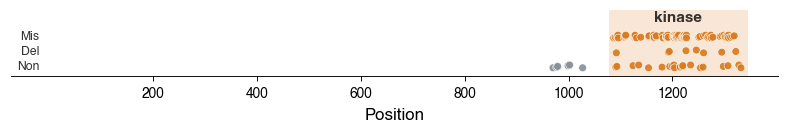

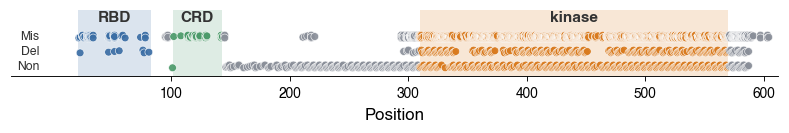

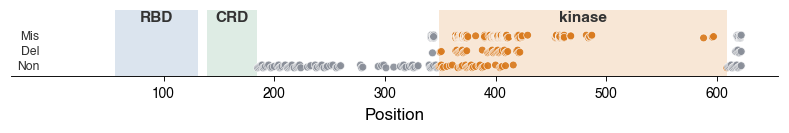

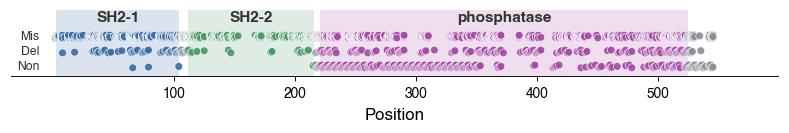

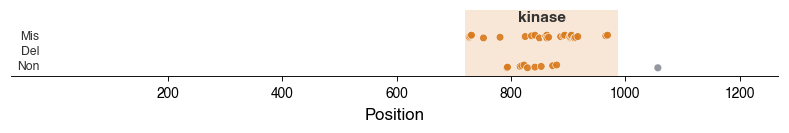

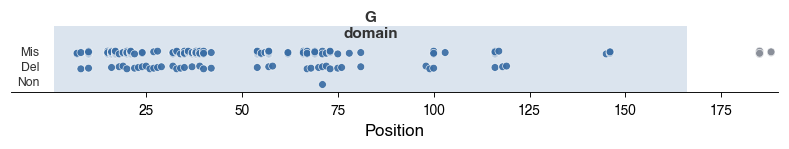

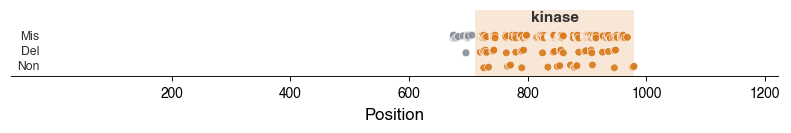

  3E HGFR   3DKC   58 DN positions  [canonical kinase pose] +ATP/MG -> 3e_structure_met.png


  3F ARAF   9AXM  324 DN positions  [canonical kinase pose] -> 3f_structure_araf.png


  3G CRAF   8CPD   66 DN positions  [curated view] +CRAF protomer 2 spheres -> 3g_structure_craf.png


  S3C SHP2   2SHP  367 DN positions  [curated view] -> s3c_structure_shp2.png


  S3D ERBB2  3PP0   23 DN positions  [canonical kinase pose] -> s3d_structure_erbb2.png


  S3E KRAS   1XD2   58 DN positions  [curated view] +SOS1 spheres -> s3e_structure_sos1kras.png


  S3G EGFR   2GS6  106 DN positions  [canonical kinase pose] -> s3g_structure_egfr.png


  S3H SHP2   3TKZ  367 DN positions  [orient] -> s3h_structure_shp2_nsh2.png


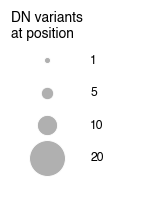

In [11]:
EXEMPLARS = [
    ("met",   "3E", "3DKC", "active site, ATP-bound"),
    ("araf",  "3F", "9AXM", "burial"),
    ("craf",  "3G", "8CPD", "kinase-domain dimer"),
    ("shp2",  "S3C", "2SHP", "N-SH2 pY pocket"),
    ("erbb2", "S3D", "3PP0", "burial, no interface signal"),
    ("sos1kras", "S3E", "1XD2", "SOS1 catalytic + allosteric RAS sites"),
    # EGFR completes the RTK set: with MET and ERBB2 it gives three kinase
    # domains in the same canonical pose, so the DN distribution can be
    # compared fold-position by fold-position across receptors.
    ("egfr",  "S3G", "2GS6", "burial, kinase domain"),
    # Paired with S3C: the same protein's enriched interface, in a conformation
    # that can hold the ligand.
    ("shp2_nsh2", "S3H", "3TKZ", "N-SH2 with pY peptide"),
]
# Panel key -> which protein's DN calls it shows. Every key is a protein name
# except where one protein gets two panels.
PANEL_PROTEIN = {"shp2_nsh2": "shp2", "sos1kras": "kras"}
# Panels that exist ONLY as a structure, with no position track of their own.
COMPANION_PANELS = {"shp2_nsh2"}
# Panel key -> which protein's DN calls it shows, for keys that are not
# themselves protein names (a protein with a second structure panel).
STRUCT_PROTEIN = {"shp2_nsh2": "shp2"}
# Curated domain bounds, with the shading colour per domain.
DOMAINS = {
    "met":   [("kinase", 1078, 1345, "#d97b1f")],
    "araf":  [("RBD", 21, 83, "#3b6ea5"), ("CRD", 101, 143, "#4c9a6a"),
              ("kinase", 310, 570, "#d97b1f")],
    "craf":  [("RBD", 56, 131, "#3b6ea5"), ("CRD", 139, 184, "#4c9a6a"),
              ("kinase", 349, 609, "#d97b1f")],
    "shp2":  [("SH2-1", 3, 104, "#3b6ea5"), ("SH2-2", 112, 216, "#4c9a6a"),
              ("phosphatase", 221, 524, "#a64ca6")],
    "erbb2": [("kinase", 720, 987, "#d97b1f")],
    "egfr":  [("kinase", 712, 979, "#d97b1f")],
    "kras":  [("G domain", 1, 166, "#3b6ea5")],
}

# All three variant types, one row each, so the nonsense inversion seen in 3C
# is visible position by position.
dn_all = dn_pool[dn_pool.is_dn]
per_pos = (dn_all.groupby(["protein", "Position", "Mutation Type"]).size()
           .rename("n_dn").reset_index())
per_pos.to_csv(FIG / "fig3eg_dn_per_position.tsv", sep="\t", index=False)

for key, panel, pdb, mech in EXEMPLARS:
    prot = PANEL_PROTEIN.get(key, key)
    sub = dn_all[dn_all.protein == prot]
    if sub.empty:
        print(f"  {prot}: no DN variants, skipped")
        continue
    by_type = {mt: sorted(g.Position.dropna().astype(int))
               for mt, g in sub.groupby("Mutation Type")}
    # Trim the axis to the scanned window rather than the full protein, so
    # density is not diluted by unprofiled regions.
    scanned = pd.to_numeric(
        act.loc[act.protein == prot, "Position"], errors="coerce").dropna()
    if key in COMPANION_PANELS:
        continue          # structure-only companion panel; no separate track
    fig, _ = utils.plot_dn_positions(
        by_type, xlim=(int(scanned.min()), int(scanned.max())),
        domains=DOMAINS.get(prot, ()), dot_size=26.0)
    # No bbox_inches="tight": every protein's panel must come out at the same
    # dimensions so the six can be stacked.
    utils.save_figure(fig, FIG / f"{panel.lower()}_dn_positions_{prot}",
                      tight=False)
    plt.show()

# ---- structures, rendered here so they come from this notebook's DN calls --
# Chain assignments are the verified canonical poses
# (scripts/paint_dn_counts_pdb_structures.py). Sphere radius is an absolute
# function of the per-position DN count, identical across every render, which
# is what makes the single legend below valid for all of them.
# ---- canonical kinase-domain pose, hard-coded ---------------------------
# The Modi & Dunbrack 2019 Fig 1 view
# and saved to output/hsp90/.../kinase_fold_reference_view.txt. Pinned here as
# a literal so this notebook does not depend on that file surviving.
#
# Recipe: load 1GAG (insulin receptor kinase) as the anchor, trim to the
# kinase domain (chain A, 995-1283, N-terminal tail removed so it does not
# dominate the view), orient, then apply the four rotations to the ANCHOR'S
# ATOMS. Each subject is then cealign'ed + super'ed onto the rotated anchor,
# which physically moves it into the same frame. The rotations must precede
# the alignment: cmd.rotate(axis, angle, selection) moves only that
# selection, so rotating afterwards would leave every subject behind.
KINASE_FOLD_VIEW = (
    0.4060613811016083, -0.6507185101509094, 0.6416226029396057,
    0.3824107050895691, -0.5166869163513184, -0.7660265564918518,
    0.8299856781959534, 0.5564171671867371, 0.03903511166572571,
    0.0, 0.0, -170.91629028320312,
    -22.87476348876953, 38.59135818481445, 11.818153381347656,
    134.751708984375, 207.08087158203125, -20.0,
)
KINASE_POSE = dict(
    align_to=str(utils.PROJECT_ROOT / "data" / "structures" / "1GAG.pdb"),
    align_chain="A", align_resi=(995, 1283),
    align_rotations=[("z", 90), ("x", 180), ("y", 180), ("y", -35)],
    view=KINASE_FOLD_VIEW,
)

# Views for the three non-kinase panels, chosen by hand in PyMOL (Sriram,
# 2026-08-03) and pinned as literal `get_view` tuples. The canonical kinase
# pose is only meaningful for a kinase fold: superposing a phosphatase, a small
# GTPase or a side-to-side dimer onto it would hide exactly what these panels
# exist to show, so each gets its own curated orientation instead.
#
# A pinned view also fixes the zoom, so the canvas is sized from the view's own
# camera distance rather than from a zoom-to-fit — see `plot_structure`. Both
# routes give the same Angstroms-per-pixel, so the one sphere legend stays
# valid across all seven structures.
CURATED_VIEWS = {
    # Autoinhibited SHP2: N-SH2 wedged into the phosphatase active site.
    "shp2": (0.284320831, -0.620489001, 0.730852723,
             0.772422433, -0.303307921, -0.558001578,
             0.567910075, 0.723179936, 0.393047184,
             0.000004157, -0.000051193, -179.372375488,
             18.156187057, -38.178714752, 40.519454956,
             126.141891479, 234.440658569, 20.0),
    # The ternary SOS1:RAS:RAS complex (1XD2), posed to show both RAS sites at
    # once: the catalytic CDC25 face and the distal allosteric REM face.
    "sos1kras": (0.377096891, 0.063449182, 0.923998535,
                 -0.230740711, 0.972631216, 0.027381096,
                 -0.896970034, -0.223527417, 0.381417215,
                 0.000000000, 0.000000000, -422.692687988,
                 21.653751373, 33.263061523, 50.121189117,
                 377.761657715, 467.623718262, 20.0),
    # KRAS-SOS1 on 6EPL. Retained for reference only: S3E now uses the ternary
    # 1XD2 complex, whose coordinates this view does not apply to.
    "kras_6epl": (0.145116702, -0.051358543, 0.988080680,
             0.495100737, -0.860859454, -0.117460005,
             0.856631517, 0.506244361, -0.099497758,
             0.000265162, -0.000084609, -196.457183838,
             175.049407959, 118.151290894, 253.175033569,
             161.665451050, 231.206192017, 20.0),
    # CRAF: the side-to-side kinase-domain dimer interface.
    "craf": (-0.438842148, -0.898536563, 0.007117328,
             0.897004843, -0.437598526, 0.062360406,
             -0.052918579, 0.033749510, 0.998028338,
             -0.000197858, 0.000002537, -166.853149414,
             93.667900085, 94.227424622, 108.460540771,
             104.322967529, 229.387283325, 20.0),
}

# Second-chain palette. Where a panel shows two chains that BOTH carry DNs, the
# two must be distinguishable twice over: different cartoon colour and
# different sphere colour, so a sphere is never ambiguous as to which protein
# it sits on.
SECOND_CHAIN_CARTOON = "wheat"          # tan, against the grey80 primary
# Partner label -> which protein's DN calls its spheres come from.
PARTNER_PROTEIN = {"SOS1": "sos1", "CRAF protomer 2": "craf"}
SPHERE_GREEN = (0.20, 0.65, 0.25)
SPHERE_ORANGE = (0.95, 0.55, 0.10)

CONTROLS = (utils.PROJECT_ROOT / "jessica_analysis" / "260404_files_for_sri"
            / "Annotating scores" / "pdb_controls 2")
# Every kinase-domain panel carries KINASE_POSE, so they render in one frame
# and are directly comparable. SHP2 is a phosphatase and KRAS a small GTPase —
# superposing either on a kinase fold would be meaningless, so they keep their
# own orientation and are not compared to the kinases by eye.
STRUCTS = {
    # 3DKC is the MET kinase domain with ATP and Mg2+ bound. The ligand is
    # drawn because this is the active-site exemplar: it shows the DN spheres
    # sitting around the nucleotide they occlude, rather than around an empty
    # cleft. 18 of the 47 annotated MET active-site residues lie within 5 A of
    # the ATP, and the closest contact is 2.0 A.
    "met":   dict(structure="fetch:3DKC", query_chains=("A",),
                  ligands=("ATP", "MG"), **KINASE_POSE),
    "araf":  dict(structure="fetch:9AXM", query_chains=("B",), **KINASE_POSE),
    # The CRAF dimer is deliberately NOT in the canonical kinase pose: that
    # view is chosen to show one kinase fold, and it hides the side-to-side
    # dimer interface which is the whole point of this panel. `orient` on the
    # two protomers together presents the interface instead.
    # Homodimer: chains A and B are both CRAF kinase domain (341-626), so the
    # same per-position DN counts apply to both halves. The second protomer is
    # tan with orange spheres against the primary's grey cartoon and CRAF-blue
    # spheres, so the dimer interface can be read as two distinct surfaces.
    "craf":  dict(structure=str(CONTROLS / "P04049_P04049_8CPD_AB.pdb"),
                  query_chains=("A",), view=CURATED_VIEWS["craf"],
                  partners=(dict(chain="B", label="CRAF protomer 2",
                                 color=SECOND_CHAIN_CARTOON,
                                 sphere_color=SPHERE_ORANGE),)),
    "erbb2": dict(structure="fetch:3PP0", query_chains=("A",), **KINASE_POSE),
    # 2GS6 chain A is the canonical EGFR kinase-domain monomer pose
    # (scripts/paint_dn_counts_pdb_structures.py).
    "egfr":  dict(structure="fetch:2GS6", query_chains=("A",), **KINASE_POSE),
    # SHP2 gets TWO panels, because one structure cannot carry both facts.
    #
    # S3C is the autoinhibited full-length enzyme, 2SHP, with every DN position:
    # the DN population is spread over the whole protein, more than half of it
    # phosphatase-domain and mostly buried.
    #
    # S3H is the ligand-bound N-SH2: 3TKZ, "SHP-2 N-SH2 domain in a 1:2 complex
    # with RVIpYFVPLNR" — the very complex whose surface carries the interface
    # odds ratio in S3A, alone or pooled with 3TL0's RLNpYAQLWHR. It
    # covers only residues 4-103, so it displays under a quarter of SHP2's DNs,
    # but it is the only way to show the peptide in a conformation that can
    # actually bind it: in 2SHP the N-SH2 pY cleft is closed against the
    # phosphatase active site, so a peptide placed there would depict a state
    # the structure is not in.
    #
    # The pair is the argument: this interface explains a small fraction of
    # SHP2's DNs yet is strongly enriched, and the enrichment is specific to
    # N-SH2 -- the equivalent C-SH2 pocket is DN-depleted.
    "shp2":  dict(structure="fetch:2SHP", query_chains=("A",),
                  view=CURATED_VIEWS["shp2"]),
    "shp2_nsh2": dict(protein="shp2", structure="fetch:3TKZ",
                      query_chains=("A",),
                      partners=(dict(chain="P", label="RVIpYFVPLNR peptide",
                                     color="yellow"),)),
    # 1XD2 is the TERNARY Ras:SOS:Ras-GDP complex: chains A and B are the two
    # RAS copies and chain C is SOS1 (566-1046). The ternary form is the point —
    # SOS1 engages RAS at two separate sites, the catalytic (CDC25) face and the
    # distal allosteric (REM) face, and only a structure carrying both can show
    # DNs sitting on each. A binary complex would leave the allosteric DNs
    # looking like they are simply "far from the interface".
    #
    # Both RAS copies take the SAME cartoon and sphere colour: they are far
    # apart here, so unlike the CRAF dimer there is nothing to disambiguate, and
    # colouring them alike says they are the same protein. SOS1 keeps the tan
    # cartoon with green spheres, RAS the default cartoon with orange spheres —
    # so a sphere's colour still names which protein's DN it is.
    #
    # 1XD2 is HRAS; our DN calls are KRAS. The two G domains are identical over
    # residues 1-86 and ~90% identical to 166, so position-wise transfer is safe
    # in the range the structure covers. KRAS positions beyond 166 (the HVR) are
    # absent from the structure and simply do not render — the sphere count
    # printed below reports how many landed.
    "sos1kras": dict(protein="kras", structure="fetch:1XD2",
                  query_chains=("A", "B"), view=CURATED_VIEWS["sos1kras"],
                  sphere_color=SPHERE_ORANGE,
                  partners=(dict(chain="C", label="SOS1",
                                 color=SECOND_CHAIN_CARTOON,
                                 sphere_color=SPHERE_GREEN),)),
}

# Ray-traced renders cost roughly a minute each at publication size. Set
# False to skip them on a quick re-run; the .pml files are always rewritten
# so the renders can be reproduced outside the notebook.
RENDER_STRUCTURES = True

pos_counts = (md_dn.groupby(["protein", "Position"]).size()
              .rename("n_dn").reset_index())

for key, panel, pdb, mech in EXEMPLARS:
    prot = PANEL_PROTEIN.get(key, key)
    spec = STRUCTS.get(key)
    if spec is None:
        continue
    # Derive the reported PDB from the structure actually loaded, and check it
    # against the label in EXEMPLARS. The two were allowed to drift apart once
    # (MET was labelled 5HNI while 3DKC was rendered), which is the kind of
    # error that survives into a caption.
    src = str(spec["structure"])
    loaded = (src.split(":", 1)[1].upper() if src.startswith("fetch:")
              else Path(src).stem.split("_")[2])
    assert loaded == pdb, f"{prot}: EXEMPLARS says {pdb}, STRUCTS loads {loaded}"
    counts = (pos_counts[pos_counts.protein == prot]
              .set_index("Position")["n_dn"].to_dict())
    # Partner chains that carry DNs get their counts filled in here: the CRAF
    # protomer repeats the same protein's counts (homodimer), while SOS1 in the
    # KRAS panel brings its own.
    spec = {**spec, "partners": tuple(
        {**d, "sphere_counts": (
            counts if d["label"].startswith(utils.protein_label(prot))
            else pos_counts[pos_counts.protein == PARTNER_PROTEIN[d["label"]]]
                 .set_index("Position")["n_dn"].to_dict())}
        if "sphere_color" in d else d
        for d in spec.get("partners", ()))}
    spec = {k: v for k, v in spec.items() if k != "protein"}
    stem = FIG / f"{panel.lower()}_structure_{key}"
    # Spheres take the protein's own colour, held constant across every
    # structure it appears in.
    # Spheres take the protein's own colour unless the panel overrides it —
    # which it does where two chains both carry DNs and the pair has to be
    # told apart by colour.
    utils.plot_structure(
        stem, sphere_counts=counts, run=RENDER_STRUCTURES,
        sphere_color=spec.pop("sphere_color",
                              utils.PROTEIN_SPHERE_COLOR[prot]), **spec)
    posed = ("canonical kinase pose" if spec.get("view") is KINASE_FOLD_VIEW
             else "curated view" if spec.get("view") else "orient")
    extra = "".join(f" +{d['label']} spheres" for d in spec.get("partners", ())
                    if d.get("sphere_counts"))
    print(f"  {panel} {utils.protein_label(prot):6s} {loaded}  "
          f"{len(counts):3d} DN positions  [{posed}]{extra}"
          + (f" +{'/'.join(spec['ligands'])}" if spec.get("ligands") else "")
          + f" -> {stem.name}.png")

# One legend for every structure above: grey spheres, because the colour
# varies by protein and the key is about size alone.
fig, _ = utils.plot_sphere_legend()
utils.save_figure(fig, FIG / "fig3eg_sphere_legend")
plt.show()

---
# Evolutionary constraint

If DN positions are functionally special rather than merely destabilising, they
should be conserved beyond what the surrounding fold requires. Two independent
measures: phyloP across vertebrates at the codon, and Jensen-Shannon divergence
across the kinase family alignment (kinase-containing proteins only).

## S3B — evolutionary constraint by activity class

Per-residue conservation for each activity class, pooled across proteins, with
one dot per protein median overlaid. Two independent axes: phyloP
(cross-species, all 12 DN-eligible proteins) and kinase-paralog
Jensen-Shannon divergence (within-kinome, kinase-domain positions of the 7
kinase-containing proteins only).

Both are **position-level**, so they say "this site matters in evolution"
rather than "this substitution is damaging" — an axis orthogonal to the
substitution-level predictors.

The per-protein median dots are the Simpson guard and are not decoration: this
project has already been caught by a pooled test that reversed under
per-protein analysis. The brackets report a Mann-Whitney p for DN against each
other class together with the number of proteins in which the DN median
actually exceeds that class's.

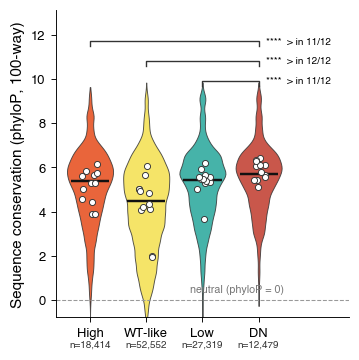

,n,median
group,,
High,18414,5.393
WT-like,52552,4.467
Low,27319,5.425
DN,12479,5.720


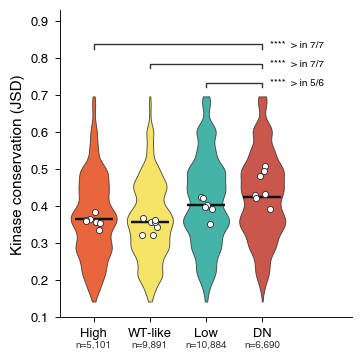

,n,median
group,,
High,5101,0.364
WT-like,9891,0.357
Low,10884,0.403
DN,6690,0.423


In [12]:
cons_pool = dn_pool[dn_pool["Mutation Type"].isin(["missense", "deletion"])].copy()
cons_pool["group"] = activity_group(cons_pool).map(
    {"high": "High", "wt-like": "WT-like", "low": "Low", "DN": "DN"})

# Axis and bracket geometry taken literally from the two source scripts —
# they differ because phyloP is unbounded while JSD is bounded on [0, 1], so a
# bracket ladder sized for phyloP would crush the JSD violins.
PANELS = [
    dict(col="phylop_vert", ylab="Sequence conservation (phyloP, 100-way)",
         stem="figs3b_phylop_by_activity_group", domain=None, proteins=None,
         ref=0.0, ref_lab="neutral (phyloP = 0)",
         geom=dict(bracket_base=None, bracket_base_pad=0.4,
                   bracket_step=0.9, bracket_tick=0.2,
                   ylim_lo_pct=0.5, ylim_lo_pad=0.5, ylim_top_pad=0.5)),
    # Restricted to kinase-domain positions of the 7 kinase-containing
    # DN-eligible proteins, as the source script does: the metric is defined
    # only within the kinase fold, so the GTPases, GEFs and the phosphatase
    # have no value and must not be pooled in as missing.
    # jsd_conservation, NOT a Shannon-entropy column. Both are per-column
    # scores on the same Modi-Dunbrack kinase alignment, but jsd_conservation is
    # Capra-Singh Jensen-Shannon divergence (window 3, BLOSUM62 background,
    # sequence weighting, gapped columns dropped) and the Shannon version had no
    # window, no background and no gap filter, and counted the alignment's
    # ANNOTATION pseudo-sequence as a sequence.
    # This panel was built on the Shannon column while its axis said JSD. JSD
    # is what the label claims, is the better-validated statistic (Capra &
    # Singh 2007, PMID 17519246, show it beats Shannon entropy at recovering
    # functional residues), and gives the cleaner per-protein result here:
    # the DN median exceeds Low in 6/6 proteins, against 5/6 on Shannon.
    dict(col="jsd_conservation", ylab="Kinase conservation (JSD)",
         stem="figs3b_kinase_conservation_by_activity_group", domain="kinase",
         proteins=["araf", "braf", "craf", "egfr", "erbb2", "met", "ret"],
         ref=None, ref_lab="",
         # Tuned for JSD's compressed range, so the bracket
         # ladder sits clear of the violins.
         geom=dict(bracket_base=0.72, bracket_step=0.052, bracket_tick=0.012,
                   ylim_lo=0.10, ylim_top_pad=0.04)),
]

for P in PANELS:
    col, ylab, stem = P["col"], P["ylab"], P["stem"]
    ref, ref_lab = P["ref"], P["ref_lab"]
    d = cons_pool.dropna(subset=[col, "group"])
    if P["domain"]:
        d = d[d.domain == P["domain"]]
    if P["proteins"]:
        d = d[d.protein.isin(P["proteins"])]
    if d.empty:
        print(f"  {col}: no data, skipped")
        continue

    groups = {g: d.loc[d.group == g, col].values
              for g in utils.ACTIVITY_GROUP_ORDER if (d.group == g).any()}

    # Per-protein medians, only where the cell has enough variants to be stable.
    med = (d.groupby(["protein", "group"])[col]
           .agg(["median", "size"]).reset_index())
    med = med[med["size"] >= utils.MIN_N_PER_PROTEIN]

    # "> in n/N": proteins where the DN median beats the comparison group's.
    wide = med.pivot(index="protein", columns="group", values="median")
    gt = {}
    for g in ("Low", "WT-like", "High"):
        if g in wide.columns and "DN" in wide.columns:
            both = wide[["DN", g]].dropna()
            gt[g] = (int((both["DN"] > both[g]).sum()), len(both))

    fig, _ = utils.plot_violin_panel(
        groups,
        group_colors=utils.ACTIVITY_GROUP_COLOR, median_bar=True,
        point_overlay=med.rename(columns={"median": "value"}),
        overlay_value_col="value", overlay_group_col="group",
        bracket_vs="DN", bracket_targets=["Low", "WT-like", "High"],
        bracket_gt_counts=gt, n_below=True,
        ref_line=ref, ref_label=ref_lab,
        hline=None, show_n=False, figsize=(3.45, 3.4), ylabel=ylab,
        xlim=(-0.6, 4.6), fs={"tick": 9, "axis": 10},
        # Literal cosmetics from the source scripts.
        widths=0.82, show_violin_medians=False, tick_labelsize=8.5,
        spine_lw=0.6,
        # The violins look rippled, and that is left alone deliberately.
        # Both metrics are POSITION-level: every substitution at a residue
        # carries that residue's single value, so the cohort holds far fewer
        # distinct values than rows, and Scott's rule picks a bandwidth narrow
        # enough to resolve them as separate modes. Widening the
        # kernel hides the discreteness rather than representing it, and
        # the bandwidth that looks smoothest is also the one that flattens
        # the between-group shape differences, so we keep the default.
        subplots_adjust=dict(left=0.20, right=0.97, top=0.97, bottom=0.15),
        **P["geom"])
    utils.save_figure(fig, FIG / stem, tight=False)
    plt.show()

    summ = d.groupby("group")[col].agg(n="size", median="median").round(3)
    display(summ.reindex([g for g in utils.ACTIVITY_GROUP_ORDER
                          if g in summ.index]))

---
# Depletion in human populations and in cancer

Both panels test the same thing — whether a class of variant is seen less often
than WT-like missense in gnomAD, All of Us and GENIE — and differ only in
resolution, so they belong together: **3I** pools over proteins, **S3F**
resolves by protein. The pooled panel is the claim; the heatmap is the evidence
that the claim is not carried by one or two proteins.

## 3I — depletion in human populations and in cancer

If these variants can dominantly inactivate the pathway from one allele they
should be selected against, and they are. Classes are compared against
wild-type-like activity as the reference.

Restricted to variants reachable by a **single nucleotide change** and
genomically mappable: a population database cannot observe anything else, so
including multi-nucleotide variants would bias the null rate downward. GENIE
uses a ≥2-tumour threshold, which removes singletons that may be
germline-miscalled.

The nonsense rows come from a second source. Truncating variants are enumerated
at the genomic level in `population_data_hgvsp.tsv` (`variant_class ==
"stop_enumerated"`), which is where the NMD-zone assignment and the matching
observation flags live; the score table's own nonsense rows are not
SNV-mappable. Missense classes come from the score table, so they use the
`DN_EV` computed in `Annotations.ipynb` rather than the older column carried in
the population table.

,n
group,
wt-like,22121
low,10256
high,7175
DN,4563
Nonsense (NMD-trigger),2487
Nonsense (NMD-escape),226


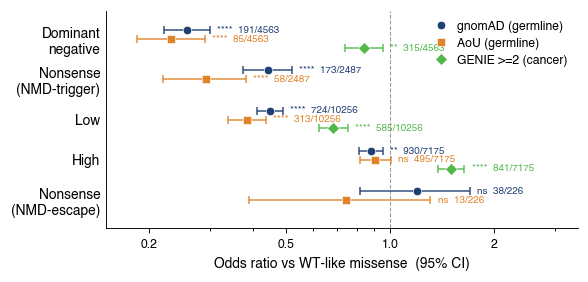

database,AoU,GENIE,gnomAD
label_key,,,
DN,0.233,0.840,0.258
Nonsense (NMD-escape),0.748,NaN,1.195
Nonsense (NMD-trigger),0.293,NaN,0.442
high,0.908,1.504,0.880
low,0.386,0.685,0.449



annotation = significance, then variants observed / variants tested


In [13]:
# --- missense classes, from the score table (DN_EV) ----------------------
miss = act[act.protein.isin(utils.DN_ELIGIBLE)
           & (act["Mutation Type"] == "missense")].copy()
miss["group"] = activity_group(miss)
miss = miss[(miss.min_nt_changes == 1) & (miss.gnomad_mappable == True)]
miss["obs_gnomAD"] = miss.in_gnomad == True
miss["obs_AoU"] = miss.in_aou == True
miss["obs_GENIE"] = pd.to_numeric(miss.genie_count, errors="coerce").ge(2)

# --- nonsense classes, from the genomically-enumerated stop set -----------
stops = pd.read_csv(utils.POPULATION_HGVSP, sep="\t", low_memory=False)
stops = stops[(stops.variant_class == "stop_enumerated")
              & stops.protein.isin(utils.DN_ELIGIBLE)].copy()
stops["group"] = np.where(
    stops.nmd_zone.astype(str).str.contains("trigger|triggering", case=False,
                                            na=False),
    "Nonsense (NMD-trigger)", "Nonsense (NMD-escape)")
stops["obs_gnomAD"] = stops.in_gnomad == True
stops["obs_AoU"] = stops.in_aou == True
stops["obs_GENIE"] = False   # enumerated stops carry no GENIE key

KEEP = ["protein", "group", "obs_gnomAD", "obs_AoU", "obs_GENIE"]
snv = pd.concat([miss[KEEP], stops[KEEP]], ignore_index=True)
display(snv.group.value_counts().rename("n").to_frame())

# Classes tested. WT-like is the reference arm of every test, so it is used
# but never plotted as a row.
CLASSES = ["DN", "Nonsense (NMD-trigger)", "low", "high",
           "Nonsense (NMD-escape)"]
GENIE_MIN_COUNT = 2

rows = []
for db in ("gnomAD", "AoU", "GENIE"):
    col = f"obs_{db}"
    for cls in CLASSES:
        # Truncating variants are not expected to drive cancer recurrence and
        # the enumerated stop set has no GENIE key, so GENIE tests missense only.
        if db == "GENIE" and cls.startswith("Nonsense"):
            continue
        g = snv[snv.group == cls]
        ref = snv[snv.group == "wt-like"]
        if len(g) < 10:
            continue
        o, tt = int(g[col].sum()), len(g)
        r_obs, r_tot = int(ref[col].sum()), len(ref)
        res = fisher_or(o, tt - o, r_obs, r_tot - r_obs)

        res.update(database=db, label_key=cls, n=tt, observed=o)
        rows.append(res)

dep = pd.DataFrame(rows).rename(columns={"or_": "or"})
dep["q"] = bh(dep.p.values)
dep["stars"] = dep.q.map(stars)
# "*** 46/2644": significance, then variants observed in the database out of
# variants tested — the counts the odds ratio is computed from.
dep["annot"] = dep.apply(lambda r: f"{r.stars}  {r.observed}/{r.n}", axis=1)
dep.to_csv(FIG / "fig3i_class_depletion_pooled.tsv", sep="\t", index=False)

# Exactly the original figure's five rows. WT-like is the reference the odds
# ratios are computed against, so it has no row: its OR is 1 by construction.
CLASS_ORDER = [
    ("DN",                     "Dominant\nnegative"),
    ("Nonsense (NMD-trigger)", "Nonsense\n(NMD-trigger)"),
    ("Low",                    "Low"),
    ("High",                   "High"),
    ("Nonsense (NMD-escape)",  "Nonsense\n(NMD-escape)"),
]
KEY = {"DN": "DN", "low": "Low", "high": "High",
       "Nonsense (NMD-trigger)": "Nonsense (NMD-trigger)",
       "Nonsense (NMD-escape)": "Nonsense (NMD-escape)"}
pooled = dep.assign(**{"class": dep.label_key.map(KEY)}).rename(
    columns={"observed": "n_obs", "n": "n_tot"})

fig, _ = utils.plot_class_depletion_pooled(
    pooled, class_order=CLASS_ORDER,
    genie_legend_label=f"GENIE >={GENIE_MIN_COUNT} (cancer)")
utils.save_figure(fig, FIG / "fig3i_depletion_pooled", tight=False)
plt.show()
display(dep.pivot(index="label_key", columns="database", values="or").round(3))
print("\nannotation = significance, then variants observed / variants tested")

## S3F — per-protein depletion heatmap

The same tests as 3I, resolved by protein. Colour is the observed fraction;
borders mark significance (grey q < 0.05, black q < 0.01). Borders rather than
asterisks keep the cells legible at this size.

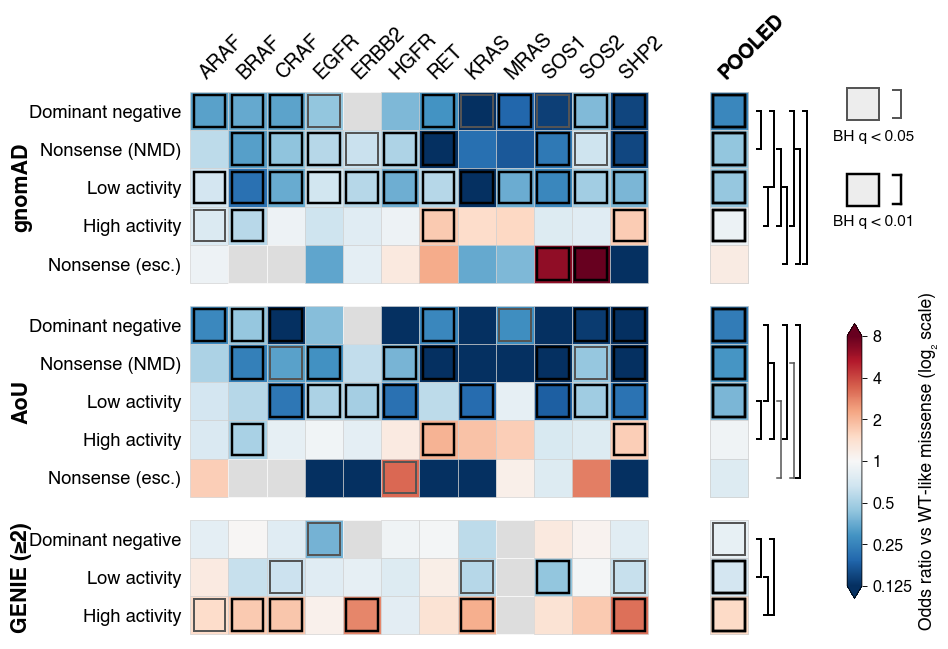

row blocks: gnomAD (5), AoU (5), GENIE (3)
brackets drawn: 18 of 23 pairs


scope,POOLED,araf,braf,craf,egfr,erbb2,kras,met,mras,ret,shp2,sos1,sos2
cls,,,,,,,,,,,,,
DN,0.26,0.32,0.34,0.33,0.44,NaN,0.12,0.39,0.19,0.29,0.15,0.14,0.40
High,0.88,0.73,0.56,0.90,0.65,0.77,1.45,0.90,1.55,1.73,1.69,0.76,0.77
Low,0.45,0.68,0.21,0.35,0.67,0.56,0.11,0.36,0.36,0.55,0.38,0.26,0.49
Nonsense (NMD-escape),1.19,0.89,NaN,NaN,0.34,0.82,0.35,1.22,0.39,2.15,0.00,6.33,21.45
Nonsense (NMD-trigger),0.44,0.58,0.32,0.43,0.55,0.63,0.21,0.53,0.17,0.07,0.15,0.23,0.65


In [14]:
# Row blocks exactly as the existing figure: each database contributes an
# ordered set of class rows, and GENIE's block is shorter because stop-gain
# variants have no cancer observations — the two nonsense classes are shown
# for gnomAD and All of Us only. Keeping them separate matters: NMD-triggering
# nonsense loses one allele outright, so it is the reference against which the
# DN depletion is judged, while NMD-escaping nonsense is the near-neutral
# control that should sit close to WT-like.
GROUPS = [
    ("gnomAD", ["DN", "Nonsense (NMD-trigger)", "Low", "High",
                "Nonsense (NMD-escape)"]),
    ("AoU",    ["DN", "Nonsense (NMD-trigger)", "Low", "High",
                "Nonsense (NMD-escape)"]),
    ("GENIE",  ["DN", "Low", "High"]),
]
CLASS_SHORT = {
    "DN": "Dominant negative",
    "Nonsense (NMD-trigger)": "Nonsense (NMD)",
    "Low": "Low activity",
    "High": "High activity",
    "Nonsense (NMD-escape)": "Nonsense (esc.)",
}
# snv carries the activity classes lower-case and the nonsense classes spelled
# out; map to the row keys used above.
TO_ROW_KEY = {"DN": "DN", "low": "Low", "high": "High",
              "Nonsense (NMD-trigger)": "Nonsense (NMD-trigger)",
              "Nonsense (NMD-escape)": "Nonsense (NMD-escape)"}
snv["row_key"] = snv.group.map(TO_ROW_KEY)

rows = []
for db, classes in GROUPS:
    col = f"obs_{db}"
    scopes = [(p, g) for p, g in snv.groupby("protein")] + [("POOLED", snv)]
    for scope, gp in scopes:
        ref = gp[gp.group == "wt-like"]
        if len(ref) < 10:
            continue
        r_obs, r_tot = int(ref[col].sum()), len(ref)
        for cls in classes:
            g = gp[gp.row_key == cls]
            if len(g) < 10:
                continue
            o, tt = int(g[col].sum()), len(g)
            res = fisher_or(o, tt - o, r_obs, r_tot - r_obs)
            res.update(database=db, scope=scope, cls=cls, n=tt,
                       frac_obs=o / tt)
            rows.append(res)
hm = pd.DataFrame(rows).rename(columns={"or_": "or"})
# BH within each database block — the comparisons in a block are one family.
hm["q"] = np.nan
for db, idx in hm.groupby("database").groups.items():
    hm.loc[idx, "q"] = bh(hm.loc[idx, "p"].values)
hm.to_csv(FIG / "figs3f_depletion_per_protein.tsv", sep="\t", index=False)

# All-pairwise between-class tests on the POOLED rates, which drive the bracket
# ladder to the right of the POOLED column. The question is not only "is this
# class depleted" but "is it depleted *more* than the next class" — whether DN
# is more depleted than NMD-triggering nonsense is the comparison that makes
# the DN signal mean something beyond loss of function. Ignores protein: these
# are the pooled rates. BH within each database block, as with the cells.
pw_rows = []
for db, classes in GROUPS:
    sub = hm[(hm.database == db) & (hm.scope == "POOLED")].set_index("cls")
    present = [c for c in classes if c in sub.index and int(sub.loc[c, "n"]) > 0]
    block = []
    for i in range(len(present)):
        for j in range(i + 1, len(present)):
            a, b = present[i], present[j]
            ta, tb = int(sub.loc[a, "n"]), int(sub.loc[b, "n"])
            oa = int(round(sub.loc[a, "frac_obs"] * ta))
            ob = int(round(sub.loc[b, "frac_obs"] * tb))
            pv = stats.fisher_exact([[oa, ta - oa], [ob, tb - ob]],
                                    alternative="two-sided").pvalue
            # Haldane correction on the point estimate only; the p is exact.
            num, den = (oa + 0.5) * (tb - ob + 0.5), (ta - oa + 0.5) * (ob + 0.5)
            block.append(dict(database=db, class_a=a, class_b=b,
                              or_a_vs_b=num / den, p=pv))
    if block:
        qs = bh([r["p"] for r in block])
        for r, q in zip(block, qs):
            r["q"] = q
        pw_rows.extend(block)
pairwise = pd.DataFrame(pw_rows)
pairwise.to_csv(FIG / "figs3f_pooled_pairwise.tsv", sep="\t", index=False)

# (scope, database, class) -> (odds ratio, q, n). The renderer treats a missing
# key, n == 0 or a non-finite OR as no-data grey.
# itertuples would rename the "or" column (a keyword), so iterate rows.
lut = {(r.scope if r.scope != "POOLED" else "Pooled", r.database, r.cls):
       (float(r["or"]), float(r["q"]), int(r["n"]))
       for _, r in hm.iterrows()}
MIN_COUNT = 2
# No title: the panel is captioned in the figure, and dropping it frees the
# strip the significance key sits in. The colourbar is nudged up so its rotated
# label clears the bottom edge instead of being clipped by the tight bbox.
fig, _ = utils.plot_class_depletion_heatmap(
    lut, groups=GROUPS, class_labels=CLASS_SHORT,
    col_order=[p for p in utils.DN_ORDER if p in set(hm.scope)] + ["Pooled"],
    pairwise=pairwise, genie_min_count=MIN_COUNT,
    cbar_dy=0.05, cbar_h_frac=0.50)
utils.save_figure(fig, FIG / "figs3f_depletion_heatmap")
plt.show()
print("row blocks: " + ", ".join(f"{db} ({len(cs)})" for db, cs in GROUPS))
print(f"brackets drawn: {int((pairwise.q < 0.05).sum())} of {len(pairwise)} pairs")
display(hm.pivot_table(index="cls", columns="scope", values="or",
                       aggfunc="first").round(2))


---
## Outputs

Everything above is written to `output/figures/fig3/`, with the underlying
statistics beside each panel as a `.tsv` so any number quoted in the text can
be traced to the test that produced it.

- **3E–G / S3C–E** structural renders come from
  `scripts/paint_dn_counts_pdb_structures.py` (PyMOL); the position tracks here
  are their matching halves.